# A* vs Dijkstra Algorithm Comparison

This notebook compares the A* and Dijkstra path planning algorithms using the AI-Based Autonomous Navigation System.

**Objectives:**
- Visualize how each algorithm explores the grid
- Compare performance metrics (nodes explored, path length, time)
- Understand when to use each algorithm

In [1]:
import sys
import os
project_root = os.path.dirname(os.getcwd())
sys.path.insert(0, project_root)
os.chdir(project_root)

import time
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

from src.simulation import GridWorld
from src.path_planning import PathPlanner
from src import config as cfg

plt.rcParams.update({
    'figure.facecolor': '#1e1e1e',
    'axes.facecolor': '#2d2d2d',
    'axes.edgecolor': '#555555',
    'axes.labelcolor': '#cccccc',
    'text.color': '#ffffff',
    'xtick.color': '#aaaaaa',
    'ytick.color': '#aaaaaa',
    'grid.color': '#444444',
    'grid.alpha': 0.4,
    'font.size': 10,
})

COLOR_ASTAR = '#00DCEC'
COLOR_DIJKSTRA = '#FFD700'

print('Libraries loaded successfully!')

pygame 2.6.1 (SDL 2.28.4, Python 3.11.9)
Hello from the pygame community. https://www.pygame.org/contribute.html
Libraries loaded successfully!


## 1. Load Maps and Run Both Algorithms

In [2]:
planner = PathPlanner()

map_names = ['Simple', 'Maze', 'Warehouse', 'City Grid', 'Parking Lot', 'Hospital']
results = []

for i, name in enumerate(map_names):
    sim = GridWorld()
    sim.load_map_by_index(i)
    
    # Run A*
    path_astar = planner.astar(sim, sim.start, sim.goal)
    astar_metrics = {
        'map': name,
        'algorithm': 'A*',
        'path_length': len(path_astar) if path_astar else 0,
        'nodes_explored': planner.last_nodes_explored,
        'time_ms': round(planner.last_time_taken * 1000, 2),
        'walls': len(sim.obstacles),
    }
    
    # Run Dijkstra
    path_dijkstra = planner.dijkstra(sim, sim.start, sim.goal)
    dijkstra_metrics = {
        'map': name,
        'algorithm': 'Dijkstra',
        'path_length': len(path_dijkstra) if path_dijkstra else 0,
        'nodes_explored': planner.last_nodes_explored,
        'time_ms': round(planner.last_time_taken * 1000, 2),
        'walls': len(sim.obstacles),
    }
    
    results.append(astar_metrics)
    results.append(dijkstra_metrics)
    
    print(f'{name}: A*={astar_metrics["path_length"]} cells, {astar_metrics["nodes_explored"]} nodes | '
          f'Dijkstra={dijkstra_metrics["path_length"]} cells, {dijkstra_metrics["nodes_explored"]} nodes')

print('\nAll maps tested!')

Simple: A*=36 cells, 36 nodes | Dijkstra=36 cells, 1100 nodes
Maze: A*=49 cells, 129 nodes | Dijkstra=49 cells, 1024 nodes
Warehouse: A*=36 cells, 36 nodes | Dijkstra=36 cells, 858 nodes
City Grid: A*=38 cells, 40 nodes | Dijkstra=38 cells, 865 nodes
Parking Lot: A*=36 cells, 36 nodes | Dijkstra=36 cells, 946 nodes
Hospital: A*=0 cells, 25 nodes | Dijkstra=0 cells, 25 nodes

All maps tested!


## 2. Performance Comparison Charts

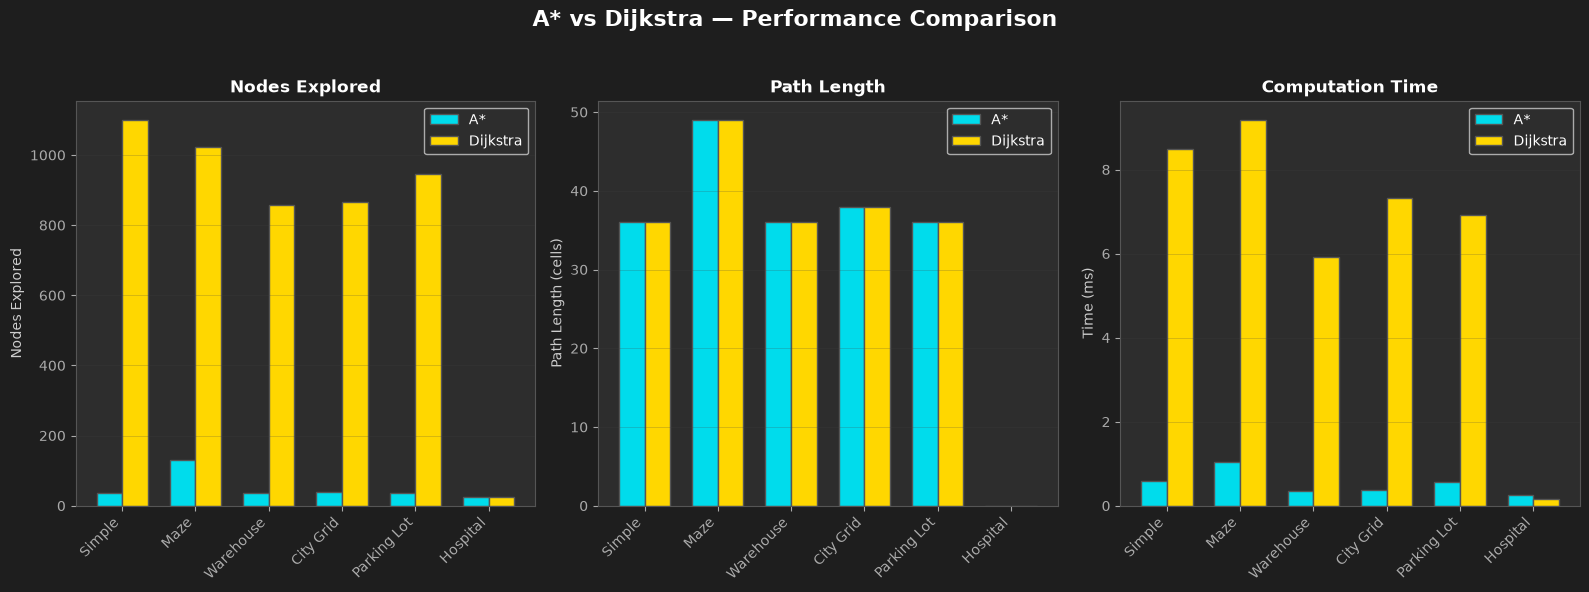

Charts saved to outputs/plots/algorithm_comparison.png


In [3]:
df = pd.DataFrame(results)
maps = df['map'].unique()

astar_data = df[df['algorithm'] == 'A*'].set_index('map')
dijkstra_data = df[df['algorithm'] == 'Dijkstra'].set_index('map')

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('A* vs Dijkstra — Performance Comparison', fontsize=16, fontweight='bold')

x = np.arange(len(maps))
width = 0.35

# Nodes Explored
bars1 = axes[0].bar(x - width/2, astar_data.loc[maps, 'nodes_explored'], width,
                     label='A*', color=COLOR_ASTAR, edgecolor='#555555')
bars2 = axes[0].bar(x + width/2, dijkstra_data.loc[maps, 'nodes_explored'], width,
                     label='Dijkstra', color=COLOR_DIJKSTRA, edgecolor='#555555')
axes[0].set_ylabel('Nodes Explored')
axes[0].set_title('Nodes Explored', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(maps, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

# Path Length
axes[1].bar(x - width/2, astar_data.loc[maps, 'path_length'], width,
            label='A*', color=COLOR_ASTAR, edgecolor='#555555')
axes[1].bar(x + width/2, dijkstra_data.loc[maps, 'path_length'], width,
            label='Dijkstra', color=COLOR_DIJKSTRA, edgecolor='#555555')
axes[1].set_ylabel('Path Length (cells)')
axes[1].set_title('Path Length', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(maps, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

# Time
axes[2].bar(x - width/2, astar_data.loc[maps, 'time_ms'], width,
            label='A*', color=COLOR_ASTAR, edgecolor='#555555')
axes[2].bar(x + width/2, dijkstra_data.loc[maps, 'time_ms'], width,
            label='Dijkstra', color=COLOR_DIJKSTRA, edgecolor='#555555')
axes[2].set_ylabel('Time (ms)')
axes[2].set_title('Computation Time', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(maps, rotation=45, ha='right')
axes[2].legend()
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('outputs/plots/algorithm_comparison.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Charts saved to outputs/plots/algorithm_comparison.png')

## 3. A* Exploration Visualization

In [4]:
sim = GridWorld()
sim.load_map_by_index(0)  # Simple map

exploration_steps = []
for state in planner.astar_animated(sim, sim.start, sim.goal, speed='fast'):
    exploration_steps.append(state)
    if state['done']:
        break

print(f'Total exploration steps: {len(exploration_steps)}')
print(f'Final path length: {len(exploration_steps[-1]["path"])} cells')

Total exploration steps: 36
Final path length: 36 cells


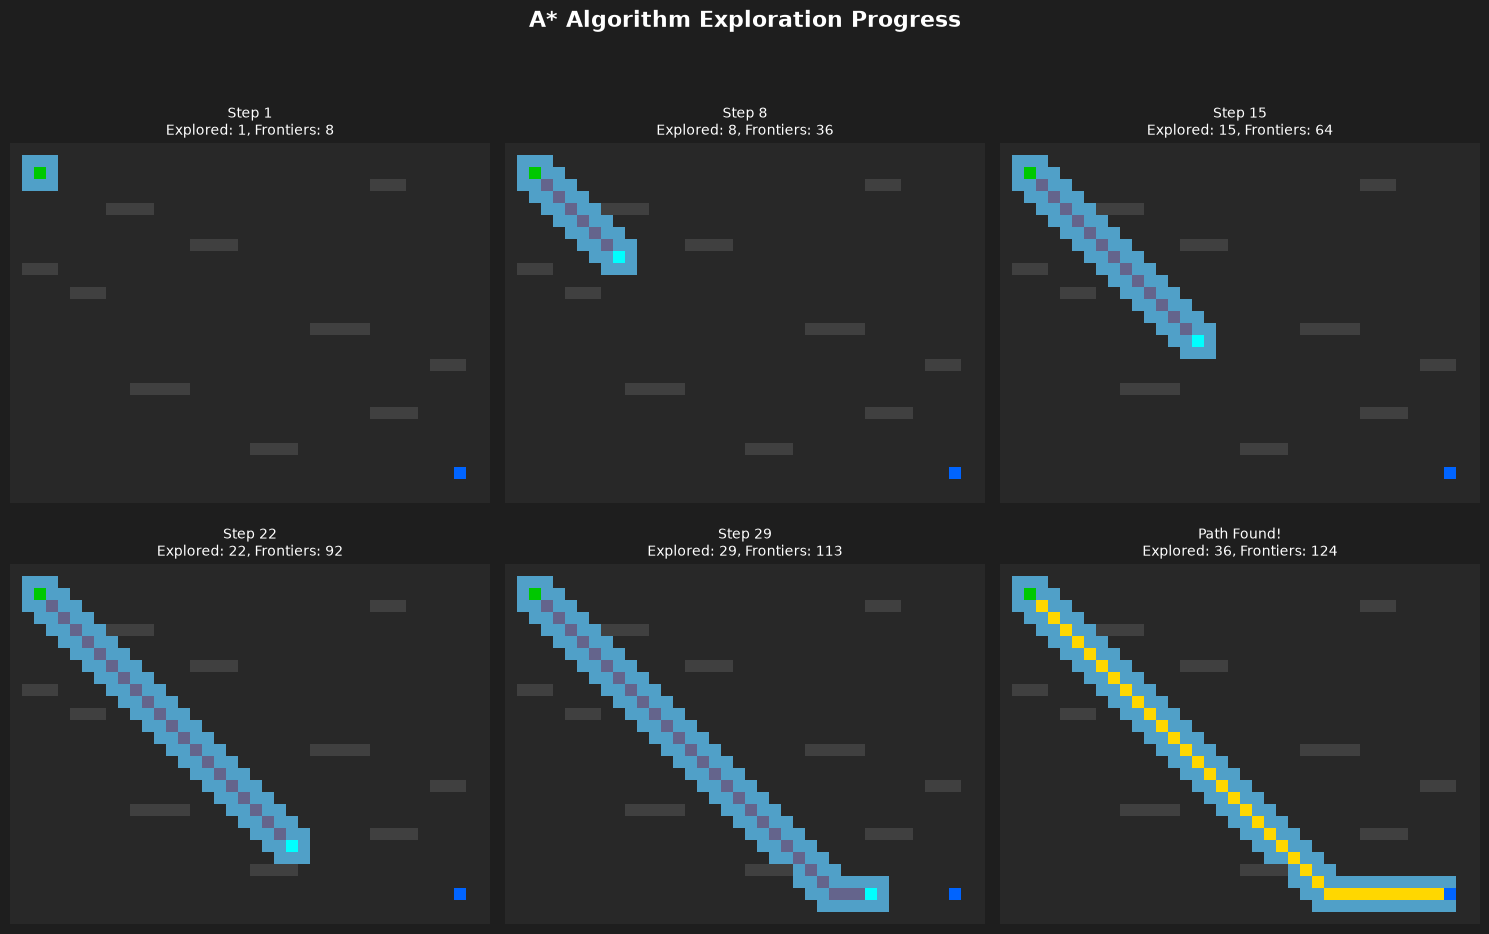

Exploration visualization saved!


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('A* Algorithm Exploration Progress', fontsize=16, fontweight='bold')

step_indices = np.linspace(0, len(exploration_steps) - 1, 6, dtype=int)

for idx, step_idx in enumerate(step_indices):
    ax = axes[idx // 3, idx % 3]
    state = exploration_steps[step_idx]
    
    grid_img = np.ones((cfg.GRID_ROWS, cfg.GRID_COLS, 3), dtype=np.uint8) * 40
    
    for r in range(cfg.GRID_ROWS):
        for c in range(cfg.GRID_COLS):
            if sim.grid[r][c] == 1:
                grid_img[r, c] = [64, 64, 64]
    
    for node in state['explored']:
        if 0 <= node[1] < cfg.GRID_ROWS and 0 <= node[0] < cfg.GRID_COLS:
            grid_img[node[1], node[0]] = [100, 100, 140]
    
    for node in state['frontier']:
        if 0 <= node[1] < cfg.GRID_ROWS and 0 <= node[0] < cfg.GRID_COLS:
            grid_img[node[1], node[0]] = [80, 160, 200]
    
    if state['current']:
        c, r = state['current']
        if 0 <= r < cfg.GRID_ROWS and 0 <= c < cfg.GRID_COLS:
            grid_img[r, c] = [0, 255, 255]
    
    for node in state['path']:
        if 0 <= node[1] < cfg.GRID_ROWS and 0 <= node[0] < cfg.GRID_COLS:
            grid_img[node[1], node[0]] = [255, 215, 0]
    
    grid_img[sim.start[1], sim.start[0]] = [0, 200, 0]
    grid_img[sim.goal[1], sim.goal[0]] = [0, 100, 255]
    
    ax.imshow(grid_img)
    status = 'Path Found!' if state['done'] else f'Step {step_idx + 1}'
    ax.set_title(f'{status}\nExplored: {len(state["explored"])}, Frontiers: {len(state["frontier"])}',
                 fontsize=10, color='#ffffff')
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('outputs/plots/astar_exploration.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Exploration visualization saved!')

## 4. Summary Table

In [6]:
print('\n=== Performance Summary ===')
print(df.to_string(index=False))

print('\n=== A* Efficiency Gain ===')
for map_name in maps:
    a = astar_data.loc[map_name]
    d = dijkstra_data.loc[map_name]
    if d['nodes_explored'] > 0:
        reduction = (1 - a['nodes_explored'] / d['nodes_explored']) * 100
        print(f'{map_name}: A* explores {reduction:.1f}% fewer nodes')


=== Performance Summary ===
        map algorithm  path_length  nodes_explored  time_ms  walls
     Simple        A*           36              36     0.60     38
     Simple  Dijkstra           36            1100     8.49     38
       Maze        A*           49             129     1.03    171
       Maze  Dijkstra           49            1024     9.18    171
  Warehouse        A*           36              36     0.34    168
  Warehouse  Dijkstra           36             858     5.93    168
  City Grid        A*           38              40     0.38    309
  City Grid  Dijkstra           38             865     7.33    309
Parking Lot        A*           36              36     0.57    184
Parking Lot  Dijkstra           36             946     6.91    184
   Hospital        A*            0              25     0.26    330
   Hospital  Dijkstra            0              25     0.16    330

=== A* Efficiency Gain ===
Simple: A* explores 96.7% fewer nodes
Maze: A* explores 87.4% fewer node

## 5. Conclusion

**Key Findings:**

1. **A*** is consistently faster** — uses heuristic to guide search toward goal

2. **Both find optimal paths** — same path length on all maps

3. **A* explores fewer nodes** — heuristic prunes unnecessary search space

4. **When to use each:**
   - **A***: Robotics, navigation, game AI (goal is known)
   - **Dijkstra**: Network routing, map apps (need all shortest paths)

5. **Time complexity**: Both O(V log V + E), but A* is faster in practice